# Validate `qmps` QPINN models

This notebook validates the package-backed QPINN models against PennyLane `default.qubit`. It uses the same model construction pattern as the PDE notebooks:

```python
models = make_models(seed=SEED, hard_boundary=True)
```

The deterministic models are checked against PennyLane. The randomized $B_2$ estimator is constructed but skipped because independent group samples are not pointwise deterministic.


## Parameters And Model Factory

Define the same `make_models(seed=SEED, hard_boundary=True)` entry point used by the PDE notebooks.


In [4]:
from __future__ import annotations

from itertools import permutations, product
import time

import matplotlib.pyplot as plt
import pennylane as qml
import torch

import qmps as qmp

SEED = 71
DTYPE = torch.float64
DEVICE = "cpu"
DIM = 2
N_QUBITS = 2
N_UPLOAD_LAYERS = 2
STRONG_LAYERS_PER_BLOCK = 3
EXP_BASE = 3.0
ENCODING_SCALE = 1.0
OUTPUT_SCALE = 0.75
DIFF_GENERATOR_PER_LAYER = False
ACOS_EPS = 1.0e-6
RANDOMIZED_B2_SAMPLES = 6
FORWARD_ATOL = 1.0e-10
FORWARD_RTOL = 1.0e-10
TIMING_BATCH = 32

qfm_config = qmp.QFMConfig(
    dim=DIM,
    n_qubits=N_QUBITS,
    n_upload_layers=N_UPLOAD_LAYERS,
    strong_layers_per_block=STRONG_LAYERS_PER_BLOCK,
    exp_base=EXP_BASE,
    encoding_scale=ENCODING_SCALE,
    output_scale=OUTPUT_SCALE,
    diff_generator_per_layer=DIFF_GENERATOR_PER_LAYER,
    acos_eps=ACOS_EPS,
    randomized_b2_samples=RANDOMIZED_B2_SAMPLES,
)
MODEL_SPECS = {
    "$B_2$-QCM": {"group": "hyperoctahedral", "input_map": "chebyshev"},
    "Randomized $B_2$-QCM": {
        "group": "randomized_hyperoctahedral",
        "input_map": "chebyshev",
        "group_sample_count": RANDOMIZED_B2_SAMPLES,
    },
    "Ordinary QCM": {"group": "none", "input_map": "chebyshev"},
    "Ordinary QFM": {"group": "none", "input_map": "raw"},
}

def make_models(seed: int = SEED, hard_boundary: bool = True):
    return qmp.make_qfm_models(
        qfm_config,
        MODEL_SPECS,
        seed=seed,
        hard_boundary=hard_boundary,
        dtype=DTYPE,
        device=DEVICE,
    )


models = make_models(seed=SEED, hard_boundary=True)
torch.set_default_dtype(DTYPE)
print(f"torch={torch.__version__}, pennylane={qml.__version__}")
print("models:", ", ".join(models))


torch=2.2.2, pennylane=0.40.0
models: $B_2$-QCM, Randomized $B_2$-QCM, Ordinary QCM, Ordinary QFM


## PennyLane Circuit Figure

Draw the shared data-uploading circuit once with PennyLane.


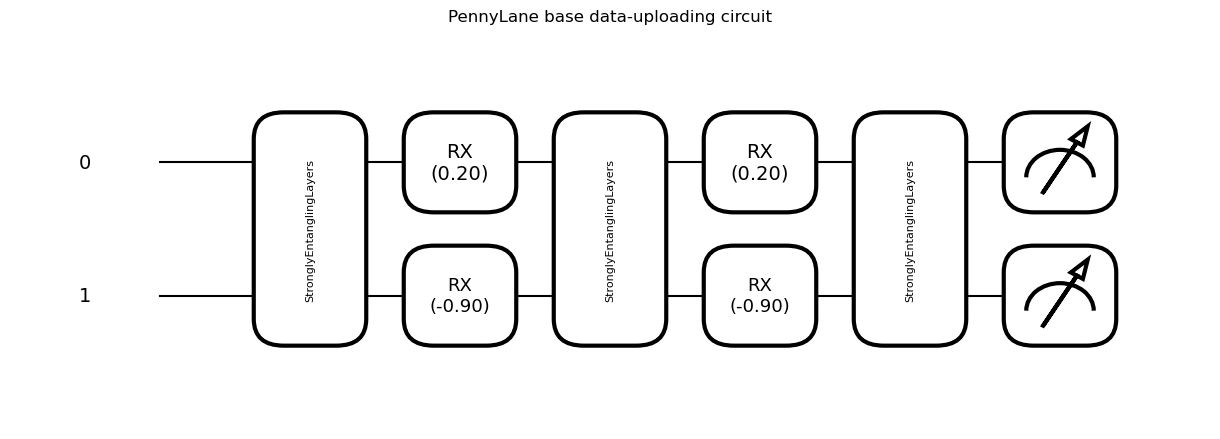

In [5]:
pl_device = qml.device("default.qubit", wires=N_QUBITS)
pl_wires = list(range(N_QUBITS))


@qml.qnode(pl_device, interface="torch", diff_method="backprop")
def pennylane_base_circuit(z_single: torch.Tensor, weights: torch.Tensor):
    for upload in range(N_UPLOAD_LAYERS):
        qml.StronglyEntanglingLayers(weights[upload], wires=pl_wires)
        for wire in pl_wires:
            coordinate = wire % DIM
            exponent = upload * N_QUBITS + wire if DIFF_GENERATOR_PER_LAYER else wire
            beta = EXP_BASE**exponent
            angle = ENCODING_SCALE * beta * z_single[coordinate]
            qml.RX(angle, wires=wire)

    qml.StronglyEntanglingLayers(weights[-1], wires=pl_wires)
    return tuple(qml.expval(qml.Projector([0], wires=wire)) for wire in pl_wires)


sample_z = torch.tensor([0.2, -0.3], dtype=DTYPE)
sample_weights = models["Ordinary QFM"].weights.detach().cpu()
fig, ax = qml.draw_mpl(pennylane_base_circuit, decimals=2)(sample_z, sample_weights)
fig.set_size_inches(12.0, 4.0)
fig.suptitle("PennyLane base data-uploading circuit", y=1.05)
plt.show()


## Forward Validation And Timing

Compare PennyLane CPU outputs against `qmps` for the deterministic models.


In [6]:
def reference_map_circuit_input(x: torch.Tensor, input_map: str) -> torch.Tensor:
    if input_map == "raw":
        return x
    if input_map == "chebyshev":
        return torch.acos(torch.clamp(x, -1.0 + ACOS_EPS, 1.0 - ACOS_EPS))
    raise ValueError(f"Unknown input_map: {input_map}")


def reference_boundary_envelope(x: torch.Tensor) -> torch.Tensor:
    return torch.prod(torch.cos(0.5 * torch.pi * x), dim=1)


def reference_group_transformed_batch(z: torch.Tensor, group: str) -> tuple[torch.Tensor, int]:
    if group == "none":
        return z, 1
    if group == "hyperoctahedral":
        signs = torch.tensor(list(product([-1.0, 1.0], repeat=DIM)), dtype=z.dtype)
        perms = torch.tensor(list(permutations(range(DIM))), dtype=torch.long)
        permuted = z[:, perms].permute(1, 0, 2)
        transformed = permuted[:, None, :, :] * signs[None, :, None, :]
        group_size = perms.shape[0] * signs.shape[0]
        return transformed.reshape(-1, DIM), group_size
    raise ValueError(f"Cannot deterministically validate group: {group}")


def pennylane_observable(z_single: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
    measured = pennylane_base_circuit(z_single, weights)
    if isinstance(measured, torch.Tensor):
        projector_values = measured.reshape(-1)
    else:
        projector_values = torch.stack([value.reshape(()) for value in measured])
    return projector_values.mean()


def pennylane_model_forward(model: qmp.ReuploadingStrongEntangleQFM, x: torch.Tensor) -> torch.Tensor:
    z = reference_map_circuit_input(x, model.input_map)
    transformed_z, group_size = reference_group_transformed_batch(z, model.group)
    weights = model.weights.detach().cpu()
    outputs = torch.stack([pennylane_observable(z_single, weights) for z_single in transformed_z])
    free_output = OUTPUT_SCALE * outputs.reshape(group_size, x.shape[0]).mean(dim=0)
    if model.hard_boundary:
        return reference_boundary_envelope(x) * free_output
    return free_output


def qmps_model_forward(model: qmp.ReuploadingStrongEntangleQFM, x: torch.Tensor) -> torch.Tensor:
    with torch.no_grad():
        return model(x).detach().cpu()


validation_x = torch.linspace(-0.8, 0.8, TIMING_BATCH, dtype=DTYPE)
validation_points = torch.stack(
    [validation_x, torch.flip(validation_x, dims=[0]) * 0.7],
    dim=1,
)

rows = []
skipped = []
for model_name, model in models.items():
    if model.group == "randomized_hyperoctahedral":
        skipped.append(model_name)
        continue

    start = time.perf_counter()
    pennylane_values = pennylane_model_forward(model, validation_points)
    pennylane_time = time.perf_counter() - start

    start = time.perf_counter()
    qmps_values = qmps_model_forward(model, validation_points)
    qmps_time = time.perf_counter() - start

    max_diff = torch.max(torch.abs(qmps_values - pennylane_values)).item()
    rows.append((model_name, pennylane_time, qmps_time, max_diff))
    assert torch.allclose(qmps_values, pennylane_values, atol=FORWARD_ATOL, rtol=FORWARD_RTOL), model_name

print(f"batch_size={validation_points.shape[0]}")
print(f"{'model':24s} {'PennyLane CPU (s)':>18s} {'qmps CPU (s)':>14s} {'max diff':>12s}")
for model_name, pennylane_time, qmps_time, max_diff in rows:
    print(f"{model_name:24s} {pennylane_time:18.6f} {qmps_time:14.6f} {max_diff:12.3e}")
if skipped:
    print("Skipped stochastic model(s): " + ", ".join(skipped))


batch_size=32
model                     PennyLane CPU (s)   qmps CPU (s)     max diff
$B_2$-QCM                          2.083241       0.008877    2.359e-16
Ordinary QCM                       0.248085       0.008046    2.498e-16
Ordinary QFM                       0.251420       0.007613    6.661e-16
Skipped stochastic model(s): Randomized $B_2$-QCM


All deterministic QPINN model checks above should run without assertion failures.
